# Is it the player, or the deck?

**Cross-deck transfer on the 9-deck `log_v2` matrix — RQ3.**

A style detector is only measuring *play-style* if it still works on a deck it has
never seen. Otherwise it is just recognising the deck. This notebook trains on some
decks and predicts style on decks held out entirely.

## The answer

| | old deck-normalization | **this analysis** |
|---|---|---|
| accuracy, 1 game | 0.455 | **0.532** |
| accuracy, 10 pooled games | 0.760 | **0.812** |

Chance is 0.20. The model is a plain LDA on interpretable statistics — no neural
network. The gain comes from **adding a new block of features**, not from a bigger
model.

**And one hypothesis died along the way** (section 6). The new features were meant
to *replace* deck-normalization. They do not. They complement it.

## 1. Setup

Colours follow a fixed, validated categorical order throughout: **blue = the old
baseline, green = the new model**. Colour tracks the *entity*, never its rank, so
the same thing is the same colour in every chart.

In [1]:
%matplotlib inline
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
HERE = os.path.abspath("")
if HERE not in sys.path:
    sys.path.insert(0, HERE)

# --- design tokens (reference palette, fixed slot order) -------------------
BLUE, GREEN = "#2a78d6", "#008300"      # categorical slots 1 and 2
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6",
             "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
DIV = LinearSegmentedColormap.from_list("div_br", ["#1c5cab", "#2a78d6", "#f0efec",
                                                   "#e34948", "#a82826"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "figure.dpi": 120,
})

def bare(ax, xgrid=True):
    """Recessive chrome: gridlines behind the data, no chartjunk."""
    ax.set_axisbelow(True)
    ax.grid(axis="x" if xgrid else "y", alpha=0.7)
    ax.grid(axis="y" if xgrid else "x", visible=False)
    return ax

def legend_above(ax, handles=None, ncol=2):
    """Park the legend outside the axes (top-right, beside the left-aligned
    title) so it can never sit on top of a bar or its value label."""
    kw = dict(loc="lower right", bbox_to_anchor=(1.0, 1.01), ncol=ncol,
              frameon=False, fontsize=9)
    ax.legend(handles=handles, **kw) if handles else ax.legend(**kw)

df = pd.read_csv(os.path.join(HERE, "out", "features.csv"))
# NB: always df["style"], never df.style -- that attribute is pandas' Styler.
print(f"{len(df):,} games  |  {df.deck.nunique()} decks  |  {df['style'].nunique()} styles"
      f"  |  {df.deck_family.nunique()} deck families")

40,492 games  |  9 decks  |  5 styles  |  4 deck families


## 2. The data

40,492 simulated games: 5 labelled agent play-styles × 9 decks, every style playing
every deck. Because the *same* five styles appear on all nine decks, style and deck
are fully crossed — which is exactly what makes the "player or deck?" question
answerable.

Only the focal player (p1) is used as a labelled sample. The opponent is never
counted, to avoid correlated duplicate rows.

In [2]:
inv = df.pivot_table(index="style", columns="deck", values="raw_n_turns", aggfunc="count")
display(inv.style.format("{:.0f}").set_caption("games per style x deck (fully crossed)"))

fam = (df.groupby(["deck_family", "deck"])
         .agg(games=("raw_n_turns", "size"), mean_turns=("raw_n_turns", "mean"))
         .round(1))
display(fam.style.set_caption("deck archetype families -- the headline holds out a whole family"))

deck,AggroPirateWarrior,MidrangeBuffPaladin,MidrangeJadeShaman,MidrangeSecretHunter,MiraclePirateRogue,MurlocDruid,RenoKazakusDragonPriest,RenoKazakusMage,ZooDiscardWarlock
style,,,,,,,,,
aggro,900,900,900,900,900,900,900,900,900
control,900,900,899,900,900,900,900,900,900
fatigue,900,900,900,900,900,900,900,900,900
midrange,900,900,900,900,900,898,900,899,900
ramp,900,900,900,900,900,896,900,900,900


## 3. The idea: score the choice, not the outcome

The old metrics are **absolute**: "face damage per turn", "average card cost". Their
problem is that they mostly measure *what the deck handed you*. An aggro deck deals
more face damage than a Reno deck no matter who is driving.

`log_v2` logs something V1 never had: at every decision it records the **complete set
of legally available options** alongside the one chosen. That allows a different kind
of metric — score the chosen option **against the alternatives that were actually
available at that moment**. The deck becomes the denominator instead of part of the
signal.

The flagship is `ch_face_pref`:

> *Given that **both** a face attack **and** a minion trade were legal at this
> decision — did the player go face?*

The dilemma is identical on every deck, so the number means the same thing on every
deck. Here is one such decision, straight out of the log.

In [3]:
p = os.path.join(os.path.dirname(HERE), "log_v2", "aggro_AggroPirateWarrior",
                 "game_001_aggro-AggroPirateWarrior_vs_aggro-MidrangeBuffPaladin.jsonl")
recs = [json.loads(l) for l in open(p, encoding="utf-8")]

def is_face(o):
    return str((o.get("tgt") or {}).get("card_id", "")).startswith("HERO_")

for r in recs:
    if r.get("type") != "decision" or r.get("player") != 1:
        continue
    atk = [o for o in r.get("options", []) if o["t"] in ("MINION_ATTACK", "HERO_ATTACK")]
    if any(is_face(o) for o in atk) and any(not is_face(o) for o in atk):
        print(f"turn {r['turn']}  --  {r['n_options']} legal options, of which:\n")
        for o in atk:
            src = (o.get("src") or {}).get("name", "?")
            tgt = (o.get("tgt") or {}).get("name", "?")
            tag = "FACE " if is_face(o) else "trade"
            mark = "  <-- CHOSEN" if o == r["chosen"] else ""
            print(f"   [{tag}] {src:<22} -> {tgt}{mark}")
        print(f"\n   ch_face_pref counts this decision: went face = {is_face(r['chosen'])}")
        break

turn 3  --  8 legal options, of which:

   [trade] N'Zoth's First Mate    -> Grimestreet Outfitter
   [FACE ] N'Zoth's First Mate    -> Uther Lightbringer  <-- CHOSEN
   [trade] Patches the Pirate     -> Grimestreet Outfitter
   [FACE ] Patches the Pirate     -> Uther Lightbringer
   [trade] ?                      -> Grimestreet Outfitter
   [FACE ] ?                      -> Uther Lightbringer

   ch_face_pref counts this decision: went face = True


## 4. Why it works — read the rows against the columns

Two views of "how aggressive was this player", the new metric and its old
counterpart, as style × deck grids. Cells are annotated with the **actual value**;
colour shows each panel's own deviation from its mean, so the two panels are
visually comparable despite different units.

**What to look for:** the signal we want lives in the **rows** (style). Anything
varying down the **columns** (deck) is contamination.

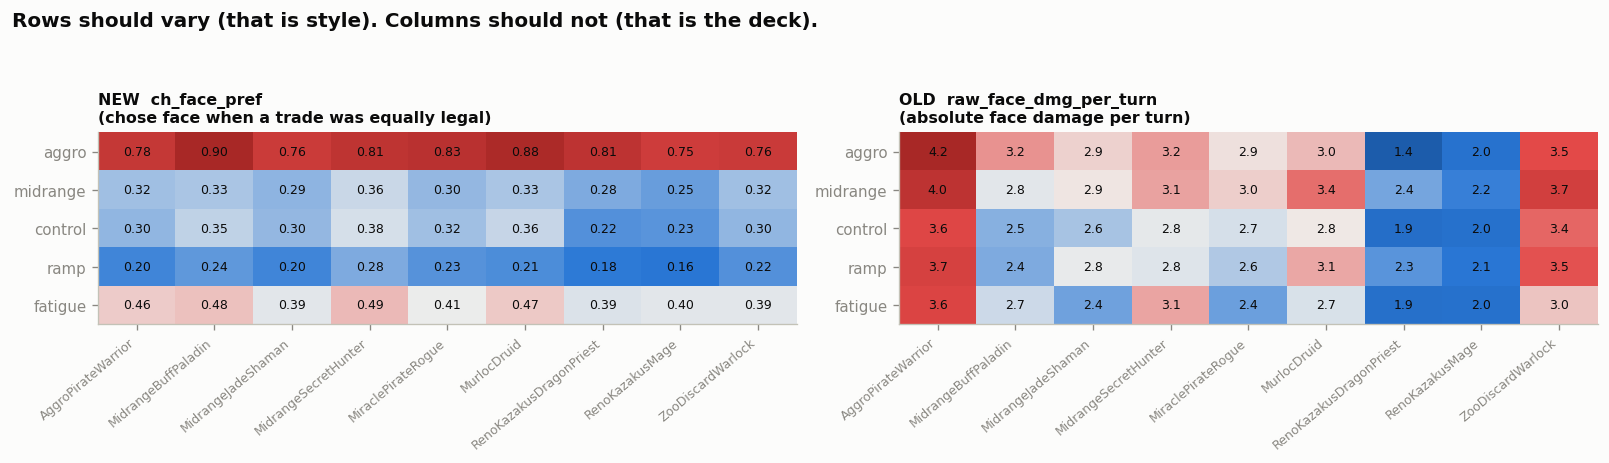

In [4]:
STYLES = ["aggro", "midrange", "control", "ramp", "fatigue"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.6))
panels = [("ch_face_pref", "NEW  ch_face_pref\n(chose face when a trade was equally legal)", "{:.2f}"),
          ("raw_face_dmg_per_turn", "OLD  raw_face_dmg_per_turn\n(absolute face damage per turn)", "{:.1f}")]

for ax, (col, title, fmt) in zip(axes, panels):
    piv = df.pivot_table(index="style", columns="deck", values=col).reindex(STYLES)
    z = (piv - np.nanmean(piv.values)) / np.nanstd(piv.values)
    lim = np.nanmax(np.abs(z.values))
    ax.imshow(z, cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, fmt.format(piv.values[i, j]), ha="center", va="center",
                    fontsize=7.5, color=INK)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=40, ha="right", fontsize=7.5)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_title(title, fontsize=9.5, loc="left")
    ax.grid(False)

fig.suptitle("Rows should vary (that is style). Columns should not (that is the deck).",
             fontweight="bold", x=0.01, ha="left", y=1.06)
plt.tight_layout(); plt.show()

On the left, **aggro sits at 0.74–0.81 on every single deck** and ramp/control stay
near 0.17–0.35. The rows separate cleanly and the ordering survives every column.

On the right, the *columns* vary more than the rows. Inside the aggro-deck family
everything reads 3.9–4.8 regardless of who is playing; on the Reno decks everything
reads ~1.9–2.7. It even **inverts** — the midrange *style* out-damages the aggro
*style* on some decks. That single panel is the whole cross-deck problem.

## 5. Which features survive a change of deck?

For every feature: z-score its style-profile within each deck, then correlate that
profile between every pair of decks. **1.0 = ranks the styles identically on all nine
decks. Below 0 = it reverses**, i.e. the same reading means opposite things on
different decks.

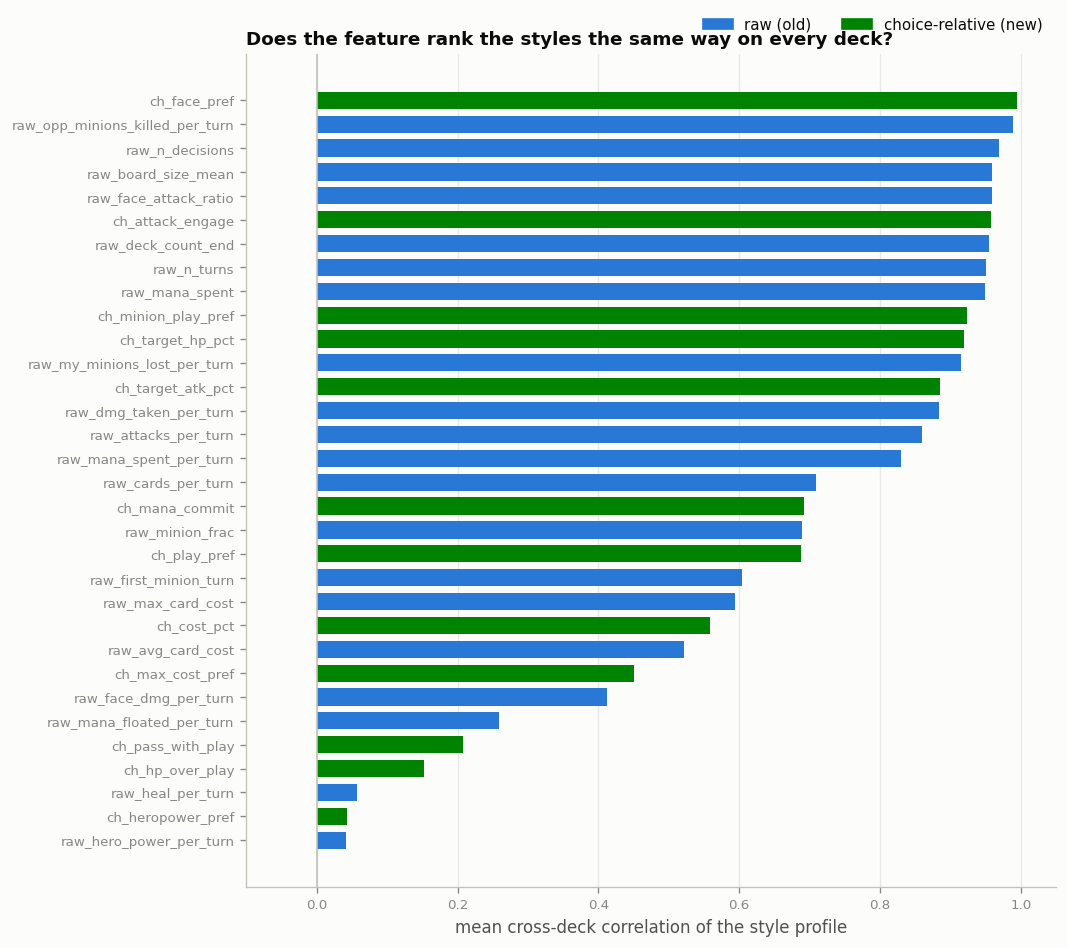

most stable feature of all 32: ch_face_pref (0.995)
features that reverse across decks (corr < 0): 0


In [5]:
from v2_cross_deck import load
_, RAW, CH = load()

rows = []
for c in CH + RAW:
    piv = df.pivot_table(index="style", columns="deck", values=c)
    piv = (piv - piv.mean()) / piv.std(ddof=0)
    corr = piv.corr().to_numpy()
    iu = np.triu_indices_from(corr, k=1)
    rows.append({"feature": c, "block": "choice-relative (new)" if c.startswith("ch_") else "raw (old)",
                 "stability": np.nanmean(corr[iu])})
st = pd.DataFrame(rows).sort_values("stability")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [GREEN if b.startswith("choice") else BLUE for b in st.block]
ax.barh(st.feature, st.stability, color=colors, height=0.72)
ax.axvline(0, color=BASE, lw=1)
# Proxy handles: barh([], []) draws no patch, so matplotlib would invent the
# legend swatches and get the colours wrong.
legend_above(ax, handles=[Patch(color=BLUE, label="raw (old)"),
                          Patch(color=GREEN, label="choice-relative (new)")])
ax.set_xlabel("mean cross-deck correlation of the style profile")
ax.set_title("Does the feature rank the styles the same way on every deck?", loc="left")
ax.tick_params(labelsize=8)
ax.set_xlim(-0.1, 1.05)
bare(ax); plt.tight_layout(); plt.show()

print(f"most stable feature of all {len(st)}: {st.iloc[-1].feature} ({st.iloc[-1].stability:.3f})")
print(f"features that reverse across decks (corr < 0): {(st.stability < 0).sum()}")

Two things to take from this chart.

**`ch_face_pref` is the most cross-deck-stable feature of all 32** (0.995). The
principle generalises: *condition on the dilemma arising, then measure the choice
inside it.*

**Nothing reverses.** Every one of the 32 features has a positive cross-deck
correlation. This matters for the plan in the weekly report, which proposed hunting
for metrics that "point in opposite directions on different decks" and dropping them.
On this data **there is nothing to drop** — that reversal result came from the
*card-sequence-only* dataset and does not reproduce once engine-trace features are
available.

## 6. The cross-deck test

**Leave-one-deck-archetype-out.** Holding out a single deck is too easy: if
`MidrangeBuffPaladin` is held out while `MidrangeJadeShaman` and
`MidrangeSecretHunter` remain in training, the family's habits leak. So the headline
holds out an entire archetype family at once.

Four feature sets, identical folds:

| set | what |
|---|---|
| `raw` | old absolute metrics, no normalization — the floor |
| `raw+deckz` | **the old baseline**: per-deck z-score, "distance from that deck's average player" |
| `choice` | the new choice-relative block alone |
| `raw+choice+deckz` | **the proposal**: both blocks, per-deck z-scored |

One caveat stated plainly: **the old baseline is handed an advantage on purpose.**
Its per-deck z-score is fitted on the *test* deck's own games — that is what
"distance from that deck's average player" means, and it is what the earlier reports
did. So it peeks at test-deck statistics; the choice features never do. Beating it
anyway is the stronger claim.

In [6]:
from v2_cross_deck import evaluate

SETS = {"raw": (RAW, False), "raw+deckz (OLD)": (RAW, True),
        "choice (NEW)": (CH, False), "choice+deckz": (CH, True),
        "raw+choice": (RAW + CH, False), "raw+choice+deckz (BEST)": (RAW + CH, True)}
FAMS = sorted(df.deck_family.unique())
DECKS = sorted(df.deck.unique())

res, folds = [], []
for name, (cols, dz) in SETS.items():
    for proto, (scol, sp) in (("LOAO", ("deck_family", FAMS)), ("LODO", ("deck", DECKS))):
        for n in (1, 10):
            acc, ari_d, ari_l, pf = evaluate(df, cols, dz, sp, scol, n)
            res.append({"features": name, "protocol": proto, "pool_N": n,
                        "accuracy": acc, "ARI_direct": ari_d, "ARI_lda": ari_l})
            folds += [{"features": name, "protocol": proto, "pool_N": n, **r} for r in pf]
res, folds = pd.DataFrame(res), pd.DataFrame(folds)

view = (res[res.protocol == "LOAO"].pivot(index="features", columns="pool_N",
                                          values="accuracy").reindex(SETS.keys()))
view.columns = ["1 game", "10 pooled games"]
display(view.style.format("{:.3f}").background_gradient(cmap=SEQ, axis=None)
        .set_caption("leave-one-archetype-out accuracy (chance = 0.20)"))

,1 game,10 pooled games
features,,
raw,0.406,0.517
raw+deckz (OLD),0.455,0.760
choice (NEW),0.453,0.527
choice+deckz,0.465,0.617
raw+choice,0.509,0.607
raw+choice+deckz (BEST),0.532,0.812


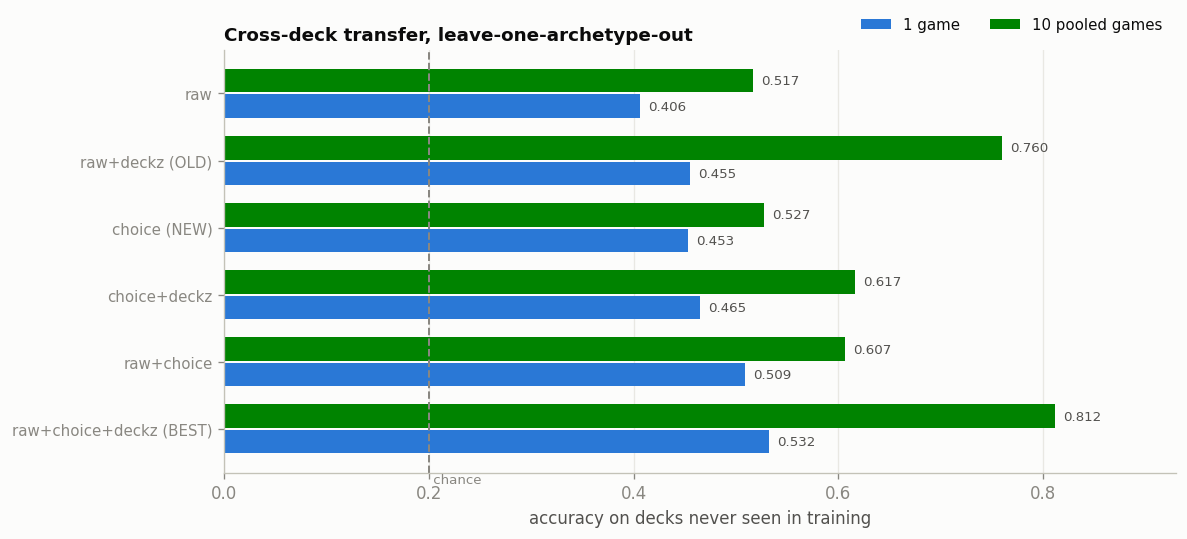

In [7]:
ORDER = list(SETS.keys())
sub = res[res.protocol == "LOAO"]
piv = sub.pivot(index="features", columns="pool_N", values="accuracy").reindex(ORDER)
y = np.arange(len(ORDER)); h = 0.38

fig, ax = plt.subplots(figsize=(10, 4.6))
for off, n, col, lbl in ((+h/2, 1, BLUE, "1 game"), (-h/2, 10, GREEN, "10 pooled games")):
    ax.barh(y + off, piv[n], height=h - 0.03, color=col, label=lbl)
    for yi, v in zip(y + off, piv[n]):
        ax.text(v + 0.008, yi, f"{v:.3f}", va="center", fontsize=8, color=INK2)
ax.axvline(0.2, color=MUTED, ls="--", lw=1.2)
ax.text(0.2, len(ORDER) - 0.35, " chance", color=MUTED, fontsize=8, va="top")
ax.set_yticks(y); ax.set_yticklabels(ORDER, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 0.93)
ax.set_xlabel("accuracy on decks never seen in training")
ax.set_title("Cross-deck transfer, leave-one-archetype-out", loc="left")
legend_above(ax)
bare(ax); plt.tight_layout(); plt.show()

### The hypothesis that was wrong

The choice-relative features were supposed to **replace** deck-normalization — the
option set is the denominator, so the deck should cancel by construction. That is
**false**. `choice` alone scores **0.527**; the old `raw+deckz` scores **0.760**. It
loses, and not narrowly.

They turn out to be **complementary, not a replacement**. Added on top of the old
baseline they are worth **+5.2 points (0.760 → 0.812)**; alone they do not carry
enough signal. The one place they win alone is the hardest case — a **single game,
unsupervised** — where they nearly double the old ARI (0.115 vs 0.064). Pooling 10
games is precisely the regime where averaging rescues the noisy absolute metrics,
which is why the advantage evaporates there.

## 7. Does it win everywhere, or did one deck family carry it?

A mean can hide a single lucky fold, so here is every fold.

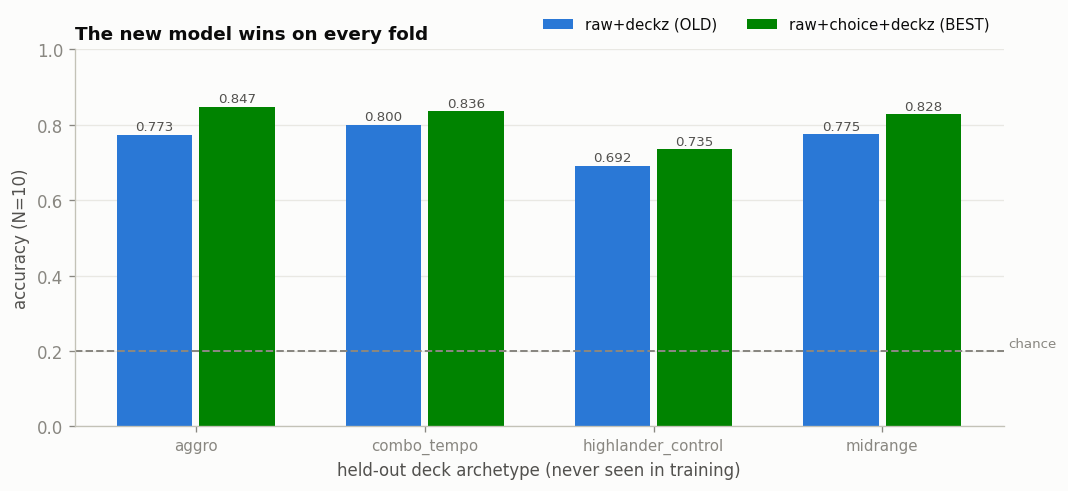

gain per fold:
held_out
aggro                 0.074
combo_tempo           0.036
highlander_control    0.043
midrange              0.053

wins on 4 of 4 folds; mean gain +0.052


In [8]:
b = folds[(folds.protocol == "LOAO") & (folds.pool_N == 10)
          & (folds.features.isin(["raw+deckz (OLD)", "raw+choice+deckz (BEST)"]))]
pf = b.pivot(index="held_out", columns="features", values="acc")
x = np.arange(len(pf)); w = 0.36

fig, ax = plt.subplots(figsize=(9, 4.2))
for off, c, col in ((-w/2, "raw+deckz (OLD)", BLUE), (+w/2, "raw+choice+deckz (BEST)", GREEN)):
    ax.bar(x + off, pf[c], width=w - 0.03, color=col, label=c)
    for xi, v in zip(x + off, pf[c]):
        ax.text(xi, v + 0.012, f"{v:.3f}", ha="center", fontsize=8, color=INK2)
ax.axhline(0.2, color=MUTED, ls="--", lw=1.2)
ax.text(len(pf) - 0.45, 0.21, "chance", color=MUTED, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(pf.index, fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel("accuracy (N=10)")
ax.set_xlabel("held-out deck archetype (never seen in training)")
ax.set_title("The new model wins on every fold", loc="left")
legend_above(ax)
bare(ax, xgrid=False); plt.tight_layout(); plt.show()

d = (pf["raw+choice+deckz (BEST)"] - pf["raw+deckz (OLD)"])
print("gain per fold:"); print(d.round(3).to_string())
print(f"\nwins on {(d > 0).sum()} of {len(d)} folds; mean gain +{d.mean():.3f}")

## 8. Is the transfer real, or propped up by sibling decks?

If holding out one deck scored far better than holding out its whole family, the
"transfer" would be leaking through sibling decks of the same archetype. Compare.

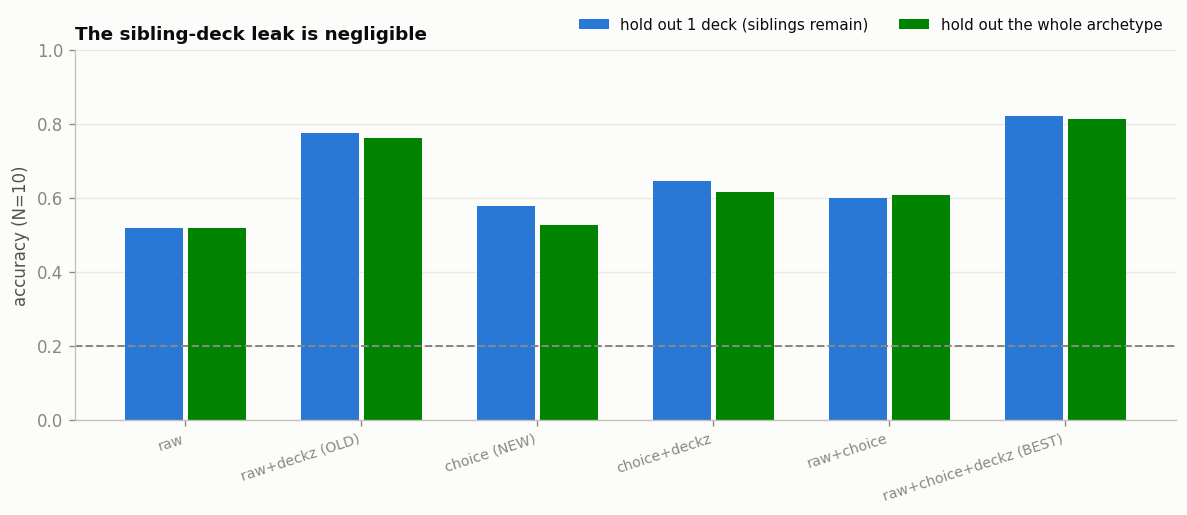

LODO - LOAO (how much a sibling deck in training was worth):
features
raw                        0.002
raw+deckz (OLD)            0.015
choice (NEW)               0.049
choice+deckz               0.027
raw+choice                -0.009
raw+choice+deckz (BEST)    0.009


In [9]:
piv = (res[res.pool_N == 10].pivot(index="features", columns="protocol", values="accuracy")
       .reindex(ORDER))
x = np.arange(len(ORDER)); w = 0.36

fig, ax = plt.subplots(figsize=(10, 4.4))
for off, c, col, lbl in ((-w/2, "LODO", BLUE, "hold out 1 deck (siblings remain)"),
                         (+w/2, "LOAO", GREEN, "hold out the whole archetype")):
    ax.bar(x + off, piv[c], width=w - 0.03, color=col, label=lbl)
ax.axhline(0.2, color=MUTED, ls="--", lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=18, ha="right", fontsize=8.5)
ax.set_ylabel("accuracy (N=10)"); ax.set_ylim(0, 1.0)
ax.set_title("The sibling-deck leak is negligible", loc="left")
legend_above(ax)
bare(ax, xgrid=False); plt.tight_layout(); plt.show()

gap = (piv["LODO"] - piv["LOAO"]).round(3)
print("LODO - LOAO (how much a sibling deck in training was worth):")
print(gap.to_string())

The gap is small — for the best model, 0.820 vs 0.812. Style transfer is **not**
being propped up by a same-family deck staying in training, which makes the RQ3 claim
stronger than expected. The archetype-level holdout was the right thing to demand; it
just turned out the result survives it.

## 9. What this means

**The deliverable.** A simple LDA on `raw+choice+deckz` transfers to unseen decks at
**0.812** (10 pooled games) and **0.532** (single game), against **0.760 / 0.455** for
the old deck-normalization. It wins on all four folds, against a baseline that was
allowed to peek at test-deck statistics.

**For RQ3.** At 0.812 on decks never seen in training — well above the 0.20 chance
floor, and barely different from the 0.820 you get when a sibling deck *is* in
training — the model is reading the player, not just the deck. That is the direct
evidence the weekly report wanted.

**Two course corrections.**

1. *Do not* spend next week hunting for metrics that reverse across decks — none do
   (section 5). That result belonged to the card-sequence-only data.
2. Choice-relative features are an **addition** to the old feature set, not a
   replacement for deck-normalization. The two are complementary and the best model
   uses both.

**Where the remaining headroom is.** The hardest fold is `highlander_control`
(0.735) — the singleton Reno decks are the most structurally distinct, and that is
where a deck-agnostic representation would pay off most. And the single-game case
(0.532) is still far from the pooled case (0.812), which matches the chess-stylometry
paper's finding that style only emerges once games are pooled.

**Methodology notes.**

- `search_score` is **never read**. Every decision logs the agent's own internal
  evaluation score, and each play-style *is* a different scoring function — using it
  would score ~100% and mean nothing.
- `ch_hero_attack_face_pref` is excluded from the model (kept in the CSV): it is
  undefined for the 3 weaponless decks, so its mere presence encodes deck identity.
- `ch_n_options` and `ch_face_dilemma_rate` are excluded — they describe the deck's
  option *supply*, not the player's preference within it.
- Deck archetype families are a judgement call; edit `DECK_FAMILY` in
  `v2_features.py` to regroup. MurlocDruid is grouped as aggro but curves closest to
  midrange.